# Data Pipeline Visualization

Three sections:
1. **Training pipeline** — what the DataLoader actually feeds to the model (domain A CelebA + domain B anime, after all transforms)
2. **Domain alignment check** — overlay canonical landmark positions on both domains to confirm they're aligned
3. **Inference on unseen image** — pick an image from `data/examples/`, run alignment + transform, show what the model will receive

In [1]:
import sys
sys.path.insert(0, '..')

import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch
from PIL import Image

from kaoanime.config import DataConfig
from kaoanime.utils import UnpairedImageDataset, create_dataloader
from kaoanime.utils.align import AlignFaceProcessor, _CELEBA_REF_128
from kaoanime.utils.transforms import get_transforms

SEED = 42
IMAGE_SIZE = 128
N_SHOW = 8   # images per row in grids

COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
LABELS = ['L-eye', 'R-eye', 'Nose', 'L-mouth', 'R-mouth']
canonical = _CELEBA_REF_128  # (5, 2) in 128×128 space

## Section 1 — Training pipeline

Shows a batch straight from the DataLoader: tensors converted back to images for inspection.
Domain A: direct `Resize((128,128))`. Domain B: fixed anime crop (scale=1.20, shift_y=−0.02) then resize.

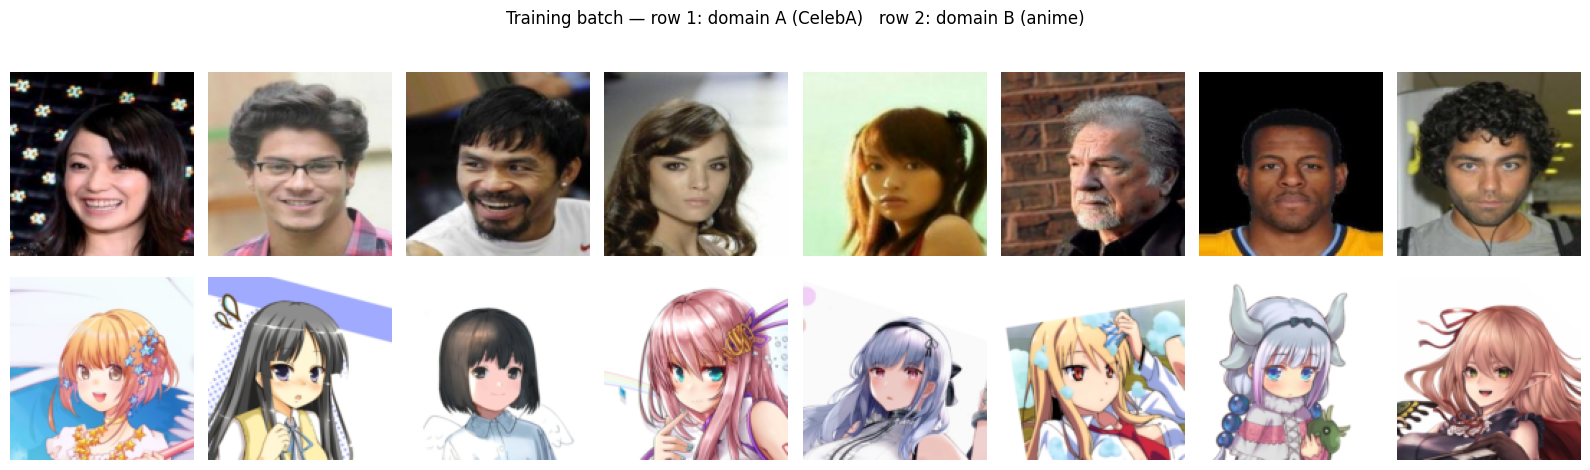

In [2]:
cfg = DataConfig()

dataset = UnpairedImageDataset(
    cfg.root_a,
    cfg.root_b,
    IMAGE_SIZE,
    align_a=cfg.align_a,
    anime_scale=cfg.anime_scale,
    anime_shift_x=cfg.anime_shift_x,
    anime_shift_y=cfg.anime_shift_y,
)

dl = create_dataloader(dataset, batch_size=N_SHOW, shuffle=True, num_workers=0)
batch = next(iter(dl))

def tensor_to_img(t: torch.Tensor) -> np.ndarray:
    """[-1,1] CHW tensor → HWC uint8."""
    return ((t.permute(1, 2, 0).numpy() * 0.5 + 0.5) * 255).clip(0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2, 5))
fig.suptitle('Training batch — row 1: domain A (CelebA)   row 2: domain B (anime)', fontsize=12)
for i in range(N_SHOW):
    axes[0, i].imshow(tensor_to_img(batch['A'][i]))
    axes[0, i].axis('off')
    axes[1, i].imshow(tensor_to_img(batch['B'][i]))
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## Section 2 — Domain alignment check

Overlay CelebA canonical landmark positions (colored ×) on both domain A and domain B images **after their respective transforms** but **before** the final train augmentation.  
If transforms are tuned correctly, face features in both rows should land near the same crosses.

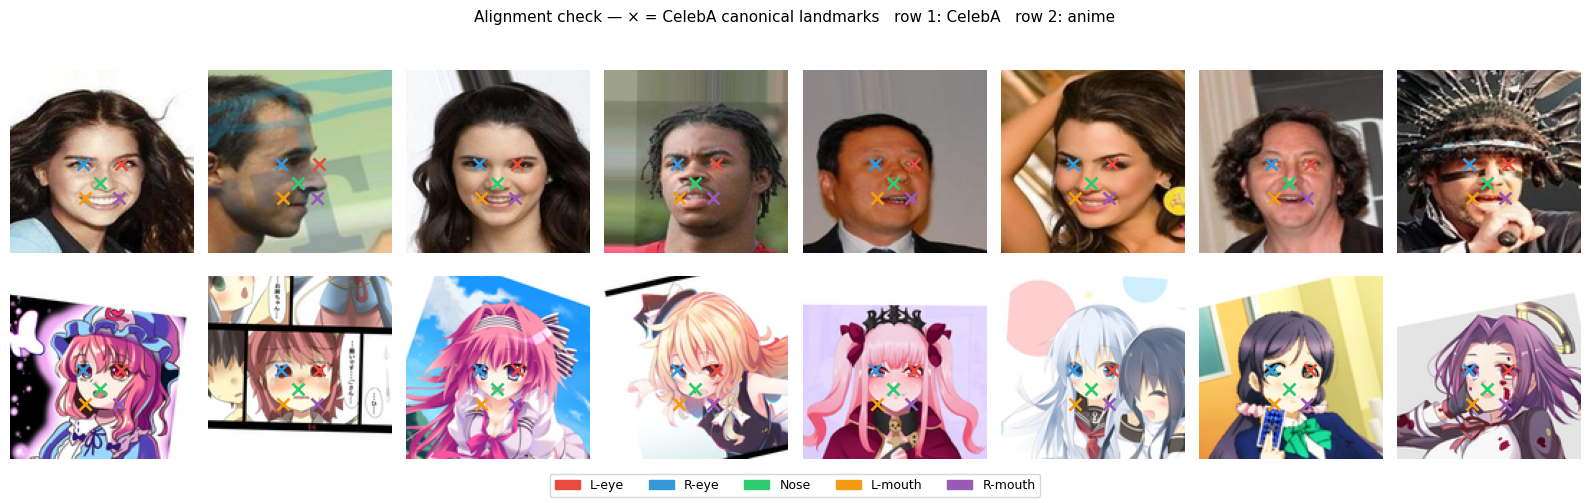

In [3]:
from kaoanime.utils.dataset import _anime_crop

rng = random.Random(SEED)
exts = {'.jpg', '.jpeg', '.png'}

def sample_paths(root, n):
    files = [p for p in Path(root).iterdir() if p.suffix.lower() in exts]
    return rng.sample(files, min(n, len(files)))

def resize_direct(path, size):
    img = Image.open(path).convert('RGB')
    return img.resize((size, size), Image.LANCZOS)

a_paths = sample_paths(cfg.root_a, N_SHOW)
b_paths = sample_paths(cfg.root_b, N_SHOW)

a_imgs = [np.array(resize_direct(p, IMAGE_SIZE)) for p in a_paths]
b_imgs = [
    np.array(
        _anime_crop(Image.open(p).convert('RGB'), cfg.anime_scale, cfg.anime_shift_x, cfg.anime_shift_y)
        .resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
    )
    for p in b_paths
]

fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2, 5))
fig.suptitle('Alignment check — × = CelebA canonical landmarks   row 1: CelebA   row 2: anime', fontsize=11)
for row, imgs in enumerate([a_imgs, b_imgs]):
    for col, img in enumerate(imgs):
        ax = axes[row, col]
        ax.imshow(img)
        for (x, y), c in zip(canonical, COLORS):
            ax.plot(x, y, 'x', color=c, markersize=8, markeredgewidth=2)
        ax.axis('off')

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=9)
plt.tight_layout()
plt.show()

## Section 3 — Inference on an unseen image

Simulates the full inference pipeline for an image from `data/examples/`:
1. Load raw image
2. Run MediaPipe landmark detection
3. Warp to CelebA alignment (same target as training domain A)
4. Apply inference transform (`Resize((128,128))` + normalize to [-1,1])

The right-most column shows what the model actually receives.

W0000 00:00:1778701005.765792 1883893 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1778701005.769855 1883893 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778701005.810096 1883944 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 570.172.08), renderer: NVIDIA A100 80GB PCIe/PCIe/SSE2
W0000 00:00:1778701005.818653 1883895 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778701005.854043 1883913 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


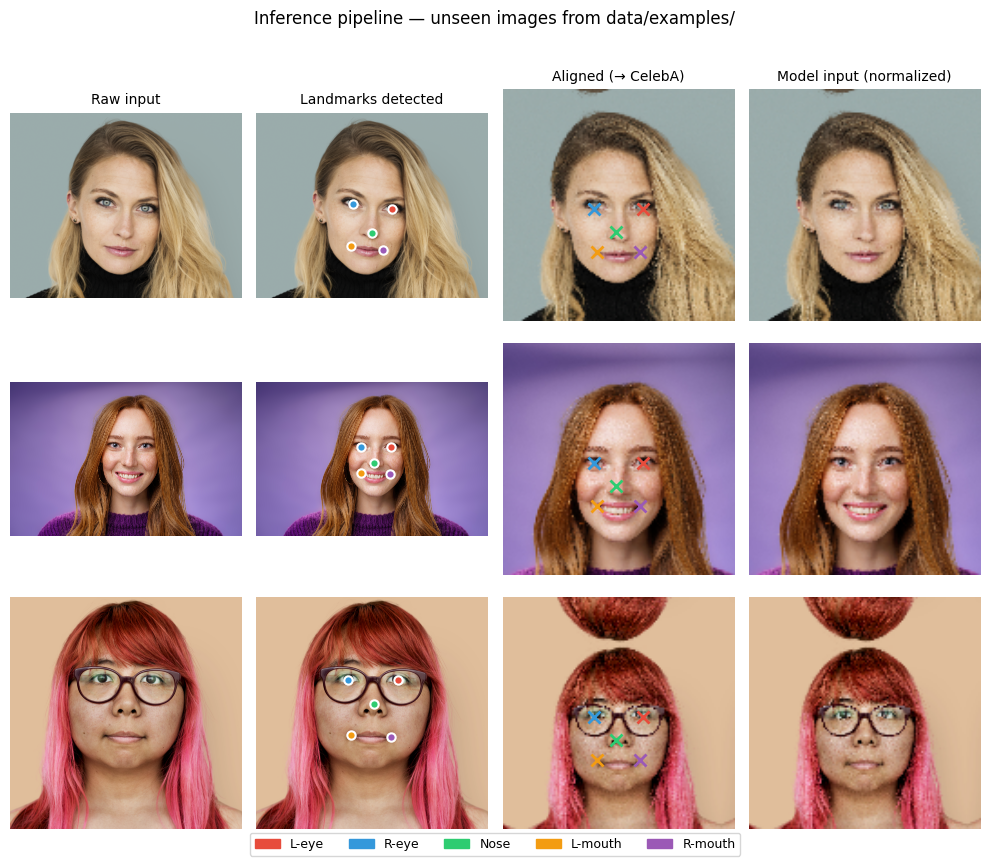

In [7]:
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision as mp_vision
from kaoanime.utils.align import _ensure_model, _src_pts, _celeba_ref

EXAMPLES_DIR = Path('../data/examples')
example_paths = sorted(EXAMPLES_DIR.glob('*'))
assert example_paths, f'No files found in {EXAMPLES_DIR}'

infer_transform = get_transforms('test', image_size=IMAGE_SIZE)

options = mp_vision.FaceLandmarkerOptions(
    base_options=mp_tasks.BaseOptions(model_asset_path=_ensure_model()),
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1,
)
landmarker = mp_vision.FaceLandmarker.create_from_options(options)

import cv2

def detect_and_align(img_rgb: np.ndarray, size: int):
    """Returns (pts_src, aligned) or (None, None) if no face."""
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = landmarker.detect(mp_img)
    if not result.face_landmarks:
        return None, None
    h, w = img_rgb.shape[:2]
    pts_src = _src_pts(result.face_landmarks[0], h, w)
    pts_dst = _celeba_ref(size)
    M, _ = cv2.estimateAffinePartial2D(pts_src, pts_dst, method=cv2.LMEDS)
    if M is None:
        return None, None
    aligned = cv2.warpAffine(img_rgb, M, (size, size),
                              flags=cv2.INTER_LINEAR,
                              borderMode=cv2.BORDER_REFLECT_101)
    return pts_src, aligned

n = len(example_paths)
fig, axes = plt.subplots(n, 4, figsize=(10, n * 2.8))
if n == 1:
    axes = axes[np.newaxis, :]

col_titles = ['Raw input', 'Landmarks detected', 'Aligned (→ CelebA)', 'Model input (normalized)']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10)

for row, path in enumerate(example_paths):
    raw = np.array(Image.open(path).convert('RGB'))
    pts_src, aligned = detect_and_align(raw, IMAGE_SIZE)

    # Col 0: raw image
    axes[row, 0].imshow(raw)
    axes[row, 0].axis('off')

    # Col 1: raw + detected landmarks
    axes[row, 1].imshow(raw)
    if pts_src is not None:
        for (x, y), c in zip(pts_src, COLORS):
            axes[row, 1].plot(x, y, 'o', color=c, markersize=6, markeredgewidth=1.5, markeredgecolor='white')
    else:
        axes[row, 1].set_xlabel('NO FACE DETECTED', color='red', fontsize=9)
    axes[row, 1].axis('off')

    # Col 2: aligned image + canonical crosses
    if aligned is not None:
        axes[row, 2].imshow(aligned, interpolation='bilinear')
        for (x, y), c in zip(canonical, COLORS):
            axes[row, 2].plot(x, y, 'x', color=c, markersize=8, markeredgewidth=2)
    else:
        # fallback: direct resize
        img_pil = Image.open(path).convert('RGB')
        fallback = np.array(img_pil.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS))
        axes[row, 2].imshow(fallback, interpolation='bilinear')
        axes[row, 2].set_xlabel('fallback: direct resize', color='orange', fontsize=9)
    axes[row, 2].axis('off')

    # Col 3: model input tensor visualized
    src_for_transform = Image.fromarray(aligned) if aligned is not None else Image.open(path).convert('RGB')
    tensor = infer_transform(src_for_transform)
    axes[row, 3].imshow(tensor_to_img(tensor), interpolation='bilinear')
    axes[row, 3].axis('off')

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=9)
plt.suptitle('Inference pipeline — unseen images from data/examples/', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

landmarker.close()